# Case 3 – State Electricity Sell Price & NPV Analysis

**Setup:** 2000 MW nuclear + fixed 2000 MW data-center demand + bidirectional grid  
(`grid_buy` = backup from grid; `grid_sell` = surplus sold to grid)

**Question:** At each US state's average retail electricity price, does a 2000 MW nuclear plant  
powering a 2000 MW data center produce a positive NPV over 30 years?

**LCOE:** ~97.4 $/MWh at 2000 MW (lower than Case 1 due to scale economies).

In [1]:
import sys
sys.path.insert(0, '/Users/svijaysh/NPP+DCfork/H2Integrate')

import os
from h2integrate import EXAMPLE_DIR
os.chdir(EXAMPLE_DIR / '32_nuclear_DC_case_3')

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from h2integrate.core.h2integrate_model import H2IntegrateModel

warnings.filterwarnings('ignore')

PLANT_MW     = 2000   # nuclear plant size
DC_DEMAND_MW = 2000   # fixed DC load
PLANT_KW     = PLANT_MW * 1e3

/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/fastkml/__init__.py:28: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


## 1. State Electricity Price Data (EIA 2023)

Average retail electricity prices by state — all sectors combined (cents/kWh).  
Source: EIA Electric Power Monthly, Table 5.6.A (2023 annual averages).

In [2]:
state_prices = {
    'AL': 12.41, 'AK': 22.54, 'AZ': 12.00, 'AR': 10.21, 'CA': 24.41,
    'CO': 12.29, 'CT': 25.77, 'DE': 13.36, 'DC': 15.02, 'FL': 13.09,
    'GA': 11.68, 'HI': 42.59, 'ID': 10.20, 'IL': 12.71, 'IN': 11.89,
    'IA':  9.95, 'KS': 11.56, 'KY': 10.55, 'LA': 10.33, 'ME': 22.43,
    'MD': 15.30, 'MA': 24.51, 'MI': 16.43, 'MN': 12.89, 'MS': 11.55,
    'MO': 11.02, 'MT': 10.88, 'NE':  9.98, 'NV': 12.11, 'NH': 23.41,
    'NJ': 17.18, 'NM': 12.44, 'NY': 21.77, 'NC': 11.79, 'ND':  9.71,
    'OH': 13.14, 'OK': 10.55, 'OR': 10.89, 'PA': 14.72, 'RI': 24.89,
    'SC': 12.07, 'SD': 11.08, 'TN': 11.59, 'TX': 12.01, 'UT': 10.15,
    'VT': 20.45, 'VA': 12.58, 'WA':  9.50, 'WV': 11.37, 'WI': 14.21,
    'WY':  8.97,
}

state_names = {
    'AL': 'Alabama',      'AK': 'Alaska',       'AZ': 'Arizona',      'AR': 'Arkansas',
    'CA': 'California',   'CO': 'Colorado',     'CT': 'Connecticut',  'DE': 'Delaware',
    'DC': 'D.C.',         'FL': 'Florida',      'GA': 'Georgia',      'HI': 'Hawaii',
    'ID': 'Idaho',        'IL': 'Illinois',     'IN': 'Indiana',      'IA': 'Iowa',
    'KS': 'Kansas',       'KY': 'Kentucky',     'LA': 'Louisiana',    'ME': 'Maine',
    'MD': 'Maryland',     'MA': 'Massachusetts','MI': 'Michigan',     'MN': 'Minnesota',
    'MS': 'Mississippi',  'MO': 'Missouri',     'MT': 'Montana',      'NE': 'Nebraska',
    'NV': 'Nevada',       'NH': 'New Hampshire','NJ': 'New Jersey',   'NM': 'New Mexico',
    'NY': 'New York',     'NC': 'North Carolina','ND': 'North Dakota', 'OH': 'Ohio',
    'OK': 'Oklahoma',     'OR': 'Oregon',       'PA': 'Pennsylvania', 'RI': 'Rhode Island',
    'SC': 'South Carolina','SD': 'South Dakota', 'TN': 'Tennessee',   'TX': 'Texas',
    'UT': 'Utah',         'VT': 'Vermont',      'VA': 'Virginia',     'WA': 'Washington',
    'WV': 'West Virginia','WI': 'Wisconsin',    'WY': 'Wyoming',
}

df_states = pd.DataFrame([
    {'state': k, 'name': state_names[k],
     'sell_price_¢/kWh': v,
     'sell_price_$/kWh': v / 100,
     'sell_price_$/MWh': v * 10}
    for k, v in state_prices.items()
]).sort_values('sell_price_$/MWh')

print(f"States: {len(df_states)}")
print(f"Price range: {df_states['sell_price_$/MWh'].min():.1f} – "
      f"{df_states['sell_price_$/MWh'].max():.1f} $/MWh")
print(f"Case 3 LCOE at {PLANT_MW} MW: ~97.4 $/MWh")
viable = df_states[df_states['sell_price_$/MWh'] >= 97.4]
print(f"States above LCOE (potentially viable): {len(viable)}")

States: 51
Price range: 89.7 – 425.9 $/MWh
Case 3 LCOE at 2000 MW: ~97.4 $/MWh
States above LCOE (potentially viable): 48


## 2. Initialize H2Integrate Model & Compute LCOE

In [3]:
h2i = H2IntegrateModel('nuclear_datacenter_config_case.yaml')
h2i.setup()

# Fix plant at 2000 MW
h2i.prob.set_val('nuclear.system_capacity',    PLANT_KW, units='kW')
h2i.prob.set_val('nuclear.electricity_demand', PLANT_KW, units='kW')
h2i.prob.set_val('grid_buy.interconnection_size',  DC_DEMAND_MW * 1e3, units='kW')
h2i.prob.set_val('grid_sell.interconnection_size', PLANT_KW,           units='kW')

h2i.run()

lcoe_kwh = h2i.prob.get_val('finance_subgroup_nuclear.LCOE', units='USD/(kW*h)')[0]
lcoe_mwh = lcoe_kwh * 1000
capex_b  = h2i.prob.get_val('nuclear.CapEx', units='USD')[0] / 1e9

print(f"Nuclear capacity : {PLANT_MW} MW")
print(f"DC demand        : {DC_DEMAND_MW} MW")
print(f"Nuclear CapEx    : ${capex_b:.2f}B")
print(f"LCOE             : ${lcoe_mwh:.2f}/MWh")
print(f"Break-even sell price: {lcoe_mwh/10:.2f} ¢/kWh")

Nuclear capacity : 2000 MW
DC demand        : 2000 MW
Nuclear CapEx    : $12.02B
LCOE             : $97.37/MWh
Break-even sell price: 9.74 ¢/kWh


## 3. NPV Loop — All 51 States

In [4]:
results = []
n = len(df_states)

for i, row in df_states.iterrows():
    sp_kwh = row['sell_price_$/kWh']
    h2i.prob.set_val('finance_subgroup_nuclear_npv.sell_price_electricity',
                     sp_kwh, units='USD/(kW*h)')
    h2i.run()
    npv_b = h2i.prob.get_val('finance_subgroup_nuclear_npv.NPV_electricity', 'USD')[0] / 1e9
    results.append({
        'state':             row['state'],
        'name':              row['name'],
        'sell_price_¢/kWh': row['sell_price_¢/kWh'],
        'sell_price_$/MWh': row['sell_price_$/MWh'],
        'NPV_$B':            npv_b,
        'viable':            npv_b > 0,
    })
    idx = len(results)
    if idx % 10 == 0 or idx == n:
        print(f"  {idx}/{n}  {row['state']:2s}  "
              f"{row['sell_price_$/MWh']:6.1f} $/MWh  →  NPV {npv_b:+.2f} $B")

df_npv = pd.DataFrame(results)
viable_count = df_npv['viable'].sum()
print(f"\nViable states (NPV > 0): {viable_count} / {n}")
print(f"Break-even sell price  : {lcoe_mwh:.2f} $/MWh  ({lcoe_mwh/10:.2f} ¢/kWh)")

  10/51  KY   105.5 $/MWh  →  NPV -0.27 $B
  20/51  GA   116.8 $/MWh  →  NPV +1.07 $B
  30/51  VA   125.8 $/MWh  →  NPV +2.14 $B
  40/51  MI   164.3 $/MWh  →  NPV +6.70 $B
  50/51  CT   257.7 $/MWh  →  NPV +17.77 $B
  51/51  HI   425.9 $/MWh  →  NPV +37.70 $B

Viable states (NPV > 0): 40 / 51
Break-even sell price  : 97.37 $/MWh  (9.74 ¢/kWh)


## 4. Results Table

In [5]:
df_display = df_npv.sort_values('sell_price_$/MWh')[[
    'state','name','sell_price_¢/kWh','sell_price_$/MWh','NPV_$B','viable'
]].copy()
df_display['NPV_$B'] = df_display['NPV_$B'].round(3)
df_display['Status'] = df_display['viable'].map({True: '✓ Viable', False: '✗ Loss'})
print(df_display.to_string(index=False))

state           name  sell_price_¢/kWh  sell_price_$/MWh  NPV_$B  viable   Status
   WY        Wyoming              8.97              89.7  -2.138   False   ✗ Loss
   WA     Washington              9.50              95.0  -1.510   False   ✗ Loss
   ND   North Dakota              9.71              97.1  -1.261   False   ✗ Loss
   IA           Iowa              9.95              99.5  -0.976   False   ✗ Loss
   NE       Nebraska              9.98              99.8  -0.941   False   ✗ Loss
   UT           Utah             10.15             101.5  -0.739   False   ✗ Loss
   ID          Idaho             10.20             102.0  -0.680   False   ✗ Loss
   AR       Arkansas             10.21             102.1  -0.668   False   ✗ Loss
   LA      Louisiana             10.33             103.3  -0.526   False   ✗ Loss
   KY       Kentucky             10.55             105.5  -0.266   False   ✗ Loss
   OK       Oklahoma             10.55             105.5  -0.266   False   ✗ Loss
   MT        Mon

## 5. Bar Charts

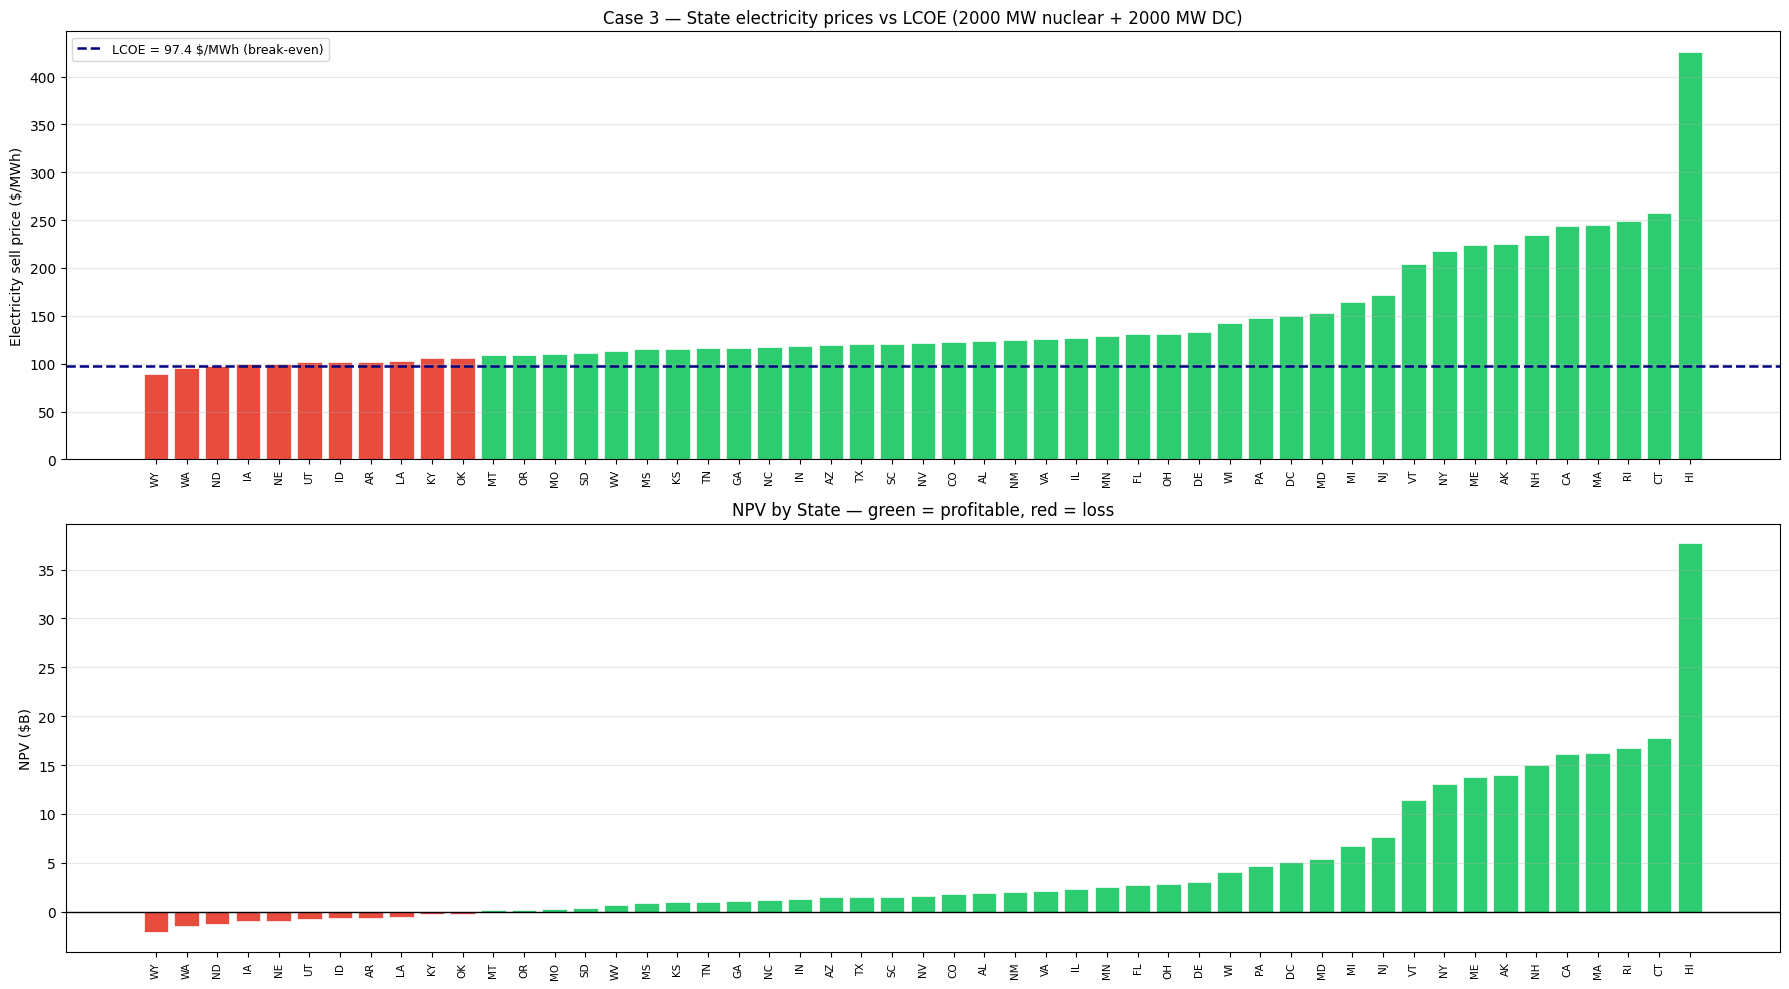

Viable: 40/51 states


In [6]:
df_sorted = df_npv.sort_values('sell_price_$/MWh')
colors = ['#2ecc71' if v else '#e74c3c' for v in df_sorted['viable']]

fig, axes = plt.subplots(2, 1, figsize=(18, 10))

# --- Sell price bar ---
ax = axes[0]
bars = ax.bar(df_sorted['state'], df_sorted['sell_price_$/MWh'], color=colors, edgecolor='white', lw=0.5)
ax.axhline(lcoe_mwh, color='navy', lw=1.8, ls='--', label=f'LCOE = {lcoe_mwh:.1f} $/MWh (break-even)')
ax.set_ylabel('Electricity sell price ($/MWh)')
ax.set_title(f'Case 3 — State electricity prices vs LCOE ({PLANT_MW} MW nuclear + {DC_DEMAND_MW} MW DC)')
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=90, labelsize=7.5)
ax.grid(axis='y', alpha=0.3)

# --- NPV bar ---
ax = axes[1]
ax.bar(df_sorted['state'], df_sorted['NPV_$B'], color=colors, edgecolor='white', lw=0.5)
ax.axhline(0, color='black', lw=1)
ax.set_ylabel('NPV ($B)')
ax.set_title('NPV by State — green = profitable, red = loss')
ax.tick_params(axis='x', rotation=90, labelsize=7.5)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Viable: {viable_count}/51 states")

## 6. US Choropleth Maps

In [7]:
import subprocess
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'nbformat>=4.2.0'],
               capture_output=True)
import plotly.io as pio
pio.renderers.default = 'notebook_connected'

In [8]:
fig = px.choropleth(
    df_npv,
    locations='state',
    locationmode='USA-states',
    color='sell_price_$/MWh',
    scope='usa',
    color_continuous_scale='RdYlGn',
    range_color=[df_npv['sell_price_$/MWh'].min(), df_npv['sell_price_$/MWh'].max()],
    labels={'sell_price_$/MWh': '$/MWh'},
    title='State Electricity Sell Prices (EIA 2023) — Case 3',
    hover_name='name',
    hover_data={'sell_price_¢/kWh': ':.2f', 'sell_price_$/MWh': ':.1f', 'state': False},
)
fig.update_layout(
    geo=dict(
        scope='usa',
        showlakes=True, lakecolor='#a8d8ea',
        showland=True,  landcolor='#f5f5f0',
        showcoastlines=True, coastlinecolor='gray',
    ),
    coloraxis_colorbar=dict(title='$/MWh', thickness=15),
    margin=dict(l=0, r=0, t=40, b=0),
    height=450,
)
fig.show()

In [9]:
max_abs = df_npv['NPV_$B'].abs().max()

fig = px.choropleth(
    df_npv,
    locations='state',
    locationmode='USA-states',
    color='NPV_$B',
    scope='usa',
    color_continuous_scale='RdYlGn',
    range_color=[-max_abs, max_abs],
    labels={'NPV_$B': 'NPV ($B)'},
    title=f'Case 3 — 30-yr NPV by State | {PLANT_MW} MW Nuclear + {DC_DEMAND_MW} MW DC | LCOE {lcoe_mwh:.1f} $/MWh',
    hover_name='name',
    hover_data={'NPV_$B': ':.2f', 'sell_price_$/MWh': ':.1f', 'viable': True, 'state': False},
)
fig.update_layout(
    geo=dict(
        scope='usa',
        showlakes=True, lakecolor='#a8d8ea',
        showland=True,  landcolor='#f5f5f0',
        showcoastlines=True, coastlinecolor='gray',
    ),
    coloraxis_colorbar=dict(title='NPV ($B)', thickness=15),
    margin=dict(l=0, r=0, t=50, b=0),
    height=450,
)
fig.show()
print(f"Green = NPV > 0 (viable). Viable: {viable_count}/51 states.")

Green = NPV > 0 (viable). Viable: 40/51 states.


In [ ]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        'State Electricity Price ($/MWh)',
        f'30-yr NPV ($B) — {viable_count}/51 states viable',
    ],
    specs=[[{'type': 'choropleth'}, {'type': 'choropleth'}]],
)

geo_style = dict(
    scope='usa', showlakes=True, lakecolor="#2f393d",
    showland=True, landcolor='#f5f5f0',
    showcoastlines=True, coastlinecolor='gray',
)

fig.add_trace(
    go.Choropleth(
        locations=df_npv['state'], locationmode='USA-states',
        z=df_npv['sell_price_$/MWh'],
        colorscale='RdYlGn',
        colorbar=dict(title='$/MWh', x=0.46, thickness=12, len=0.8),
        hovertemplate='<b>%{text}</b><br>Price: %{z:.1f} $/MWh<extra></extra>',
        text=df_npv['name'],
    ),
    row=1, col=1,
)

fig.add_trace(
    go.Choropleth(
        locations=df_npv['state'], locationmode='USA-states',
        z=df_npv['NPV_$B'],
        colorscale='RdYlGn',
        zmid=0,
        colorbar=dict(title='NPV ($B)', x=1.0, thickness=12, len=0.8),
        hovertemplate='<b>%{text}</b><br>NPV: %{z:.2f} $B<extra></extra>',
        text=df_npv['name'],
    ),
    row=1, col=2,
)

fig.update_geos(geo_style)
fig.update_layout(
    title_text=f'Case 3: {PLANT_MW} MW Nuclear + {DC_DEMAND_MW} MW DC | LCOE {lcoe_mwh:.1f} $/MWh | Break-even {lcoe_mwh/10:.2f} ¢/kWh',
    height=420, margin=dict(l=0, r=0, t=60, b=0),
)
fig.show()

## 7. Regional Summary

      region  avg_price  avg_npv  viable_states  total_states  viable_pct
 New England      235.8     15.2              6             6       100.0
     Pacific      219.9     13.3              4             5        80.0
Mid-Atlantic      162.2      6.5              6             6       100.0
     Midwest      120.5      1.5              9            12        75.0
       Texas      120.1      1.5              1             1       100.0
       South      116.0      1.0              9            12        75.0
    Mountain      111.3      0.4              5             8        62.5
    Oklahoma      105.5     -0.3              0             1         0.0


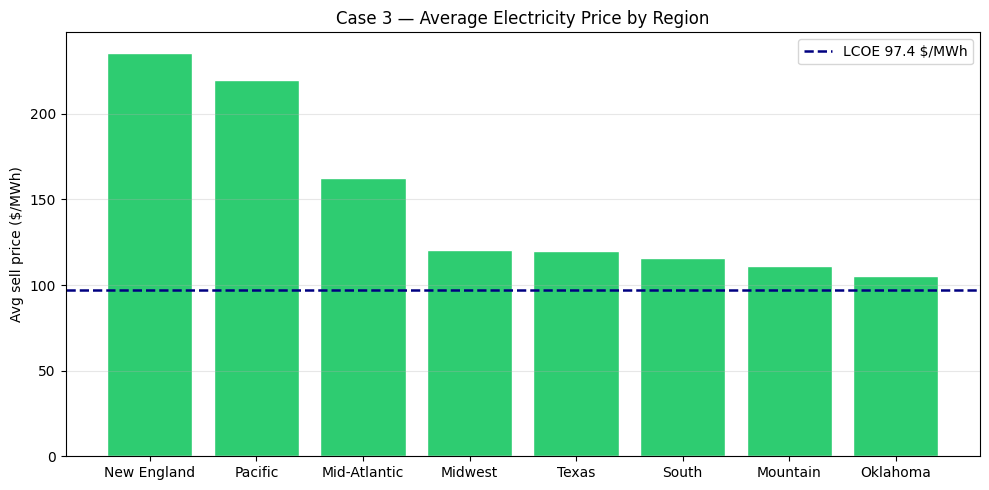

In [11]:
region_map = {
    'New England':    ['CT','ME','MA','NH','RI','VT'],
    'Mid-Atlantic':   ['DC','DE','MD','NJ','NY','PA'],
    'South':          ['AL','AR','FL','GA','KY','LA','MS','NC','SC','TN','VA','WV'],
    'Midwest':        ['IL','IN','IA','KS','MI','MN','MO','NE','ND','OH','SD','WI'],
    'Mountain':       ['AZ','CO','ID','MT','NV','NM','UT','WY'],
    'Pacific':        ['AK','CA','HI','OR','WA'],
    'Texas':          ['TX'],
    'Oklahoma':       ['OK'],
}
df_npv['region'] = df_npv['state'].map(
    {s: r for r, states in region_map.items() for s in states}
).fillna('Other')

regional = df_npv.groupby('region').agg(
    avg_price=('sell_price_$/MWh','mean'),
    avg_npv=('NPV_$B','mean'),
    viable_states=('viable','sum'),
    total_states=('viable','count'),
).reset_index()
regional['viable_pct'] = (regional['viable_states'] / regional['total_states'] * 100).round(1)
regional = regional.sort_values('avg_price', ascending=False)
print(regional.to_string(index=False, float_format='%.1f'))

fig, ax = plt.subplots(figsize=(10, 5))
colors_r = ['#2ecc71' if p >= lcoe_mwh else '#e74c3c' for p in regional['avg_price']]
ax.bar(regional['region'], regional['avg_price'], color=colors_r, edgecolor='white')
ax.axhline(lcoe_mwh, color='navy', ls='--', lw=1.8, label=f'LCOE {lcoe_mwh:.1f} $/MWh')
ax.set_ylabel('Avg sell price ($/MWh)')
ax.set_title('Case 3 — Average Electricity Price by Region')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 8. NPV Sensitivity — Price Range

In [12]:
fig = px.scatter(
    df_npv,
    x='sell_price_$/MWh', y='NPV_$B',
    color='viable',
    color_discrete_map={True: '#2ecc71', False: '#e74c3c'},
    text='state',
    title=f'Case 3: NPV vs Electricity Sell Price ({PLANT_MW} MW nuclear + {DC_DEMAND_MW} MW DC)',
    labels={'sell_price_$/MWh': 'State sell price ($/MWh)', 'NPV_$B': 'NPV ($B)'},
    hover_name='name',
)
fig.add_vline(x=lcoe_mwh, line_dash='dash', line_color='navy',
              annotation_text=f'LCOE = {lcoe_mwh:.1f} $/MWh', annotation_position='top right')
fig.add_hline(y=0, line_width=1, line_color='black')
fig.update_traces(textposition='top center', textfont_size=9)
fig.update_layout(height=500, showlegend=False)
fig.show()

## 9. Summary

In [13]:
best = df_npv.nlargest(5, 'NPV_$B')[['state','name','sell_price_$/MWh','NPV_$B']]
worst = df_npv.nsmallest(5, 'NPV_$B')[['state','name','sell_price_$/MWh','NPV_$B']]

print("=" * 60)
print(f"Case 3 — {PLANT_MW} MW Nuclear + {DC_DEMAND_MW} MW DC + Bidirectional Grid")
print(f"  LCOE               : {lcoe_mwh:.2f} $/MWh")
print(f"  Break-even price   : {lcoe_mwh/10:.2f} ¢/kWh")
print(f"  Viable states      : {viable_count} / 51")
print(f"  NPV range          : {df_npv['NPV_$B'].min():.2f} to {df_npv['NPV_$B'].max():.2f} $B")
print()
print("Top 5 states (best NPV):")
print(best.to_string(index=False, float_format='%.2f'))
print()
print("Bottom 5 states (worst NPV):")
print(worst.to_string(index=False, float_format='%.2f'))
print("=" * 60)

Case 3 — 2000 MW Nuclear + 2000 MW DC + Bidirectional Grid
  LCOE               : 97.37 $/MWh
  Break-even price   : 9.74 ¢/kWh
  Viable states      : 40 / 51
  NPV range          : -2.14 to 37.70 $B

Top 5 states (best NPV):
state          name  sell_price_$/MWh  NPV_$B
   HI        Hawaii            425.90   37.70
   CT   Connecticut            257.70   17.77
   RI  Rhode Island            248.90   16.73
   MA Massachusetts            245.10   16.28
   CA    California            244.10   16.16

Bottom 5 states (worst NPV):
state         name  sell_price_$/MWh  NPV_$B
   WY      Wyoming             89.70   -2.14
   WA   Washington             95.00   -1.51
   ND North Dakota             97.10   -1.26
   IA         Iowa             99.50   -0.98
   NE     Nebraska             99.80   -0.94
